In [14]:
import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

### Does pooled or paied input give assemblies with higehr TM-score?

for all homomultimers pdb check how many cf outputs there are also wjta is the max confidence

In [18]:
CF_DIR = Path(data_dir / "Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold")
TSV_PATH = Path(data_dir / "Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/sixth_input_homomultimers_pool_vs_pair.tsv")


def parse_confidence(conf_path: Path) -> list[tuple[str, float]]:
    return [
        (parts[0], float(parts[1]))
        for line in conf_path.read_text().strip().splitlines()
        if len(parts := line.rsplit(maxsplit=1)) == 2
    ]


def cluster_idx(path: str) -> int:
    return int(Path(path).stem.rsplit("_", 1)[-1])


def cf_stats(uniprot_id: str, n_chains: int, condition: str) -> dict:
    cols = [f"n_outputs_{condition}", f"conf_max_{condition}", f"cf_max_conf_path_{condition}"]
    null_row = dict.fromkeys(cols)

    out_dir = CF_DIR / f"{uniprot_id}x{n_chains}_{condition}_output"
    if not out_dir.exists():
        return null_row

    conf_path = out_dir / "assembled_results" / "confidence.txt"
    if not conf_path.exists():
        return {**null_row, f"n_outputs_{condition}": 0}

    entries = parse_confidence(conf_path)
    if not entries:
        return {**null_row, f"n_outputs_{condition}": 0}

    max_conf = max(e[1] for e in entries)
    best_path = min(
        (e[0] for e in entries if e[1] == max_conf),
        key=cluster_idx,
    )
    return {
        f"n_outputs_{condition}": len(entries),
        f"conf_max_{condition}": max_conf,
        f"cf_max_conf_path_{condition}": best_path,
    }


df = (
    pl.read_csv(TSV_PATH, separator="\t", comment_prefix=None)
    .rename({"#Complex ac": "complex_ac"})
    .with_columns(pl.col("complex_ac").str.strip_chars_start("HOMO_").alias("uniprot_id"))
)

rows = [
    {
        **row,
        **cf_stats(row["uniprot_id"], row["n_chains"], "pool"),
        **cf_stats(row["uniprot_id"], row["n_chains"], "pair"),
    }
    for row in df.iter_rows(named=True)
]

result = pl.DataFrame(rows)
print(result.select(["uniprot_id", "pdb_id", "n_outputs_pool", "conf_max_pool", "n_outputs_pair", "conf_max_pair"]))
print(f"\nAssembled (pool): {result['n_outputs_pool'].is_not_null().sum()} / {len(result)}")
print(f"Assembled (pair): {result['n_outputs_pair'].is_not_null().sum()} / {len(result)}")

shape: (494, 6)
┌────────────┬────────┬────────────────┬───────────────┬────────────────┬───────────────┐
│ uniprot_id ┆ pdb_id ┆ n_outputs_pool ┆ conf_max_pool ┆ n_outputs_pair ┆ conf_max_pair │
│ ---        ┆ ---    ┆ ---            ┆ ---           ┆ ---            ┆ ---           │
│ str        ┆ str    ┆ i64            ┆ f64           ┆ i64            ┆ f64           │
╞════════════╪════════╪════════════════╪═══════════════╪════════════════╪═══════════════╡
│ P27472     ┆ 6u77   ┆ 0              ┆ null          ┆ 0              ┆ null          │
│ P40579     ┆ 6uhx   ┆ 3              ┆ 85.5726       ┆ 3              ┆ 95.5387       │
│ P38777     ┆ 1ycd   ┆ 3              ┆ 86.6733       ┆ 3              ┆ 84.4018       │
│ P25502     ┆ 1zme   ┆ 3              ┆ 54.9535       ┆ 3              ┆ 65.5253       │
│ P33338     ┆ 9hdd   ┆ 3              ┆ 66.3343       ┆ 3              ┆ 79.1224       │
│ …          ┆ …      ┆ …              ┆ …             ┆ …              ┆ …         

download pdbs under data_dir/ "/Homomultimer/pdb_files"

In [9]:
import shutil
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

RCSB_URL = "https://files.rcsb.org/download/{pdb_id}.cif"
OUT_DIR = data_dir / "Homomultimer/pdb_files"
N_WORKERS = 16

# df comes from TSV cell above — only the PDBs where CF was run
pdb_ids = result["pdb_id"].to_list()  


def download_au(pdb_id: str) -> tuple[str, Path | None]:
    au_path = OUT_DIR / pdb_id / f"{pdb_id}.cif"
    if au_path.exists():
        print(f"skip  {pdb_id}")
        return pdb_id, au_path

    (OUT_DIR / pdb_id).mkdir(parents=True, exist_ok=True)
    try:
        urllib.request.urlretrieve(RCSB_URL.format(pdb_id=pdb_id), au_path)
        print(f"ok    {pdb_id}")
        return pdb_id, au_path
    except Exception as e:
        shutil.rmtree(OUT_DIR / pdb_id, ignore_errors=True)
        print(f"FAIL  {pdb_id}: {e}")
        return pdb_id, None


with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    path_map: dict[str, Path | None] = dict(
        fut.result() for fut in as_completed(pool.submit(download_au, p) for p in pdb_ids)
    )

ok    1zme
ok    1jsc
ok    1g6q
ok    2a6v
ok    3x38
ok    1f9w
ok    1ycd
ok    9hdd
ok    6uhx
ok    7m3p
ok    2nye
ok    3d6i
ok    1hqo
ok    1jzt
ok    4otm
ok    2h0r
ok    3frx
ok    5a07
ok    4a5k
ok    4xva
ok    1dvr
ok    1qcw
ok    1kyq
ok    3f7f
ok    8rwk
ok    8pio
ok    1fzy
ok    1qup
ok    2fvu
ok    2ixo
ok    4lk2
ok    6u77
ok    6kmb
ok    2p63
ok    1ist
ok    1pxt
ok    1h4p
ok    3o05
ok    4bb7
ok    5aim
ok    1jqq
ok    1pvd
ok    4uvj
ok    4j7q
ok    3eih
ok    1k61
ok    5o6b
ok    3vwa
ok    1z1a
ok    5cqs
ok    1rb4
ok    6ezm
ok    7am1
ok    5c2y
ok    6hb1
ok    5nw5
ok    3h4l
ok    4w6z
ok    4iap
ok    7ej6
ok    1q8y
ok    1tkl
ok    1m6u
ok    4am6
ok    3lsu
ok    1i21
ok    1hfb
ok    5on7
ok    1m4z
ok    1ypr
ok    4h5i
ok    2j16
ok    4ogp
ok    2oq2
ok    8dh7
ok    1zvf
ok    6jcn
ok    7pz2
ok    6cay
ok    2lh0
ok    1a3w
ok    2zw9
ok    1ebf
ok    3g3q
ok    3wi3
ok    7rsl
ok    3f3k
ok    2akp
ok    1yn8
ok    4j0x
ok    8b4k

chekc that stoichiomeztry of asemtrical unit is alo the one that i subi´mitted

In [ ]:
'''

# check that the amount chains in the cif file match the number of chains in the homomultimer mapping file
# so the number i have in homomultimers.csv as n _h´chains is the one of the asymtrics asemebly
results_subset = result.select(["pdb_id","n_chains_au"])
#n chains
homomult_chain_info = pl.read_csv(data_dir/"Homomultimer/Pipeline_prep/homomultimers.csv")
homomult_chain_info = homomult_chain_info.with_columns(pl.col("pdb_id").str.to_uppercase())
results_subset = results_subset.join(homomult_chain_info.select(["pdb_id","n_chains"]), on="pdb_id", how="left")
results_subset= results_subset.with_columns(
    chains_au = pl.when(pl.col("n_chains_au") == pl.col("n_chains")).then(True).otherwise(False).alias("chains_au")
)
'''

filter for homomultimers that have more than 2 chains

In [8]:
homomultimer_bigger_complexes = result.filter(pl.col("n_chains") > 2)

In [12]:
homomultimer_bigger_complexes.write_csv(PRJ_ROOT / "tmp/homomultimer_bigger_complexes.csv")

In [10]:
print(PRJ_ROOT / "tmp/homomultimer_bigger_complexes.csv")

/cluster/project/beltrao/kdammer/master_thesis/tmp/homomultimer_bigger_complexes.csv


In [11]:
from pathlib import Path
import polars as pl

COMBFOLD_DIR = Path("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold")

def classify_outcome(uniprot_id: str, n_chains: int, condition: str) -> tuple[str, int]:
    """
    Returns (reason, n_transform_files).
    
    reason:
      'success'          — assembled_results has PDB output
      'no_transforms_dir'— _unified_representation/transformations/ doesn't exist
                           (s1 never ran or output dir doesn't exist at all)
      'no_selfpair'      — transforms dir exists but is empty
                           (s1 ran, found no self-pair in pool DB)
      'assembly_failed'  — transforms exist but no PDB output
                           (clash / disconnected / other; need log to distinguish)
    """
    output_dir = COMBFOLD_DIR / f"{uniprot_id}x{n_chains}_{condition}_output"

    # success
    assembled_dir = output_dir / "assembled_results"
    if assembled_dir.exists() and any(assembled_dir.glob("output_clustered_*.pdb")):
        return "success", -1

    # transforms dir
    transforms_dir = output_dir / "_unified_representation" / "transformations"
    if not transforms_dir.exists():
        return "no_transforms_dir", 0

    n_tf = len(list(transforms_dir.iterdir()))
    if n_tf == 0:
        return "no_selfpair", 0

    return "assembly_failed", n_tf


records = []
for row in homomultimer_bigger_complexes.iter_rows(named=True):
    uid = row["uniprot_id"]
    n   = row["n_chains"]
    for cond in ("pool", "pair"):
        reason, n_tf = classify_outcome(uid, n, cond)
        records.append({
            "complex_ac":         row["complex_ac"],
            "condition":          cond,
            "failure_reason":     reason,
            "n_transform_files":  n_tf,
        })

outcomes = (
    pl.DataFrame(records)
    .pivot(on="condition", index="complex_ac",
           values=["failure_reason", "n_transform_files"])
    .rename({
        "failure_reason_pool":    "failure_reason_pool",
        "failure_reason_pair":    "failure_reason_pair",
        "n_transform_files_pool": "n_transforms_pool",
        "n_transform_files_pair": "n_transforms_pair",
    })
)

homomultimer_bigger_complexes = homomultimer_bigger_complexes.join(
    outcomes, on="complex_ac", how="left"
)

# Summary
for cond in ("pool", "pair"):
    col = f"failure_reason_{cond}"
    print(f"\n--- {cond} ---")
    print(homomultimer_bigger_complexes.group_by(col).len().sort("len", descending=True))


--- pool ---
shape: (4, 2)
┌─────────────────────┬─────┐
│ failure_reason_pool ┆ len │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ assembly_failed     ┆ 110 │
│ success             ┆ 65  │
│ no_selfpair         ┆ 10  │
│ no_transforms_dir   ┆ 1   │
└─────────────────────┴─────┘

--- pair ---
shape: (4, 2)
┌─────────────────────┬─────┐
│ failure_reason_pair ┆ len │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ assembly_failed     ┆ 164 │
│ success             ┆ 20  │
│ no_transforms_dir   ┆ 1   │
│ no_selfpair         ┆ 1   │
└─────────────────────┴─────┘


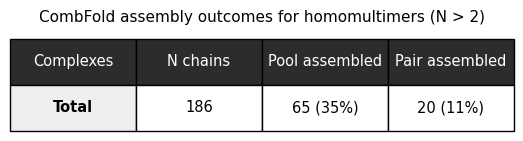

In [ ]:
#how often do eahc of them produce an output
df = homomultimer_bigger_complexes.filter(pl.col("n_chains") > 2)

t  = len(df)
ps = (df["failure_reason_pool"] == "success").sum()
qs = (df["failure_reason_pair"] == "success").sum()

rows = [["Total", str(t), f"{ps} ({100*ps/t:.0f}%)", f"{qs} ({100*qs/t:.0f}%)"]]
cols = ["Complexes", "N chains", "Pool assembled", "Pair assembled"]

fig, ax = plt.subplots(figsize=(6.5, 1.2))
ax.axis("off")
table = ax.table(cellText=rows, colLabels=cols, cellLoc="center", loc="center", bbox=[0,0,1,1])
table.auto_set_font_size(False)
table.set_fontsize(10.5)

for j in range(len(cols)):
    table[0,j].set_facecolor("#2c2c2c")
    table[0,j].set_text_props(color="white")

table[1,0].set_facecolor("#eeeeee")
table[1,0].set_text_props(fontweight="bold")

ax.set_title("CombFold assembly outcomes for homomultimers (N > 2)", fontsize=11, pad=12)
fig

run us align to get tm score for the highest confidence output for pool and highest confidence output for pairs (for thsoe complexes where poool and pair have an output)

In [32]:
homomultimers_pool_pair_outputs = homomultimer_bigger_complexes.filter(pl.col("cf_max_conf_path_pool").is_not_null() & pl.col("cf_max_conf_path_pair").is_not_null())
homomultimers_pool_pair_outputs = homomultimers_pool_pair_outputs.with_columns(
    pdb_path = pl.lit("/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/") + pl.col("pdb_id") + pl.lit("/") + pl.col("pdb_id") + pl.lit(".cif")
)


In [ ]:
#homomultimers_pool_pair_outputs.write_csv(PRJ_ROOT / "scripts/homomultimer_poll_pair_comparison//homomultimers_pool_pair_outputs.csv")
print(PRJ_ROOT / "scripts/homomultimer_poll_pair_comparison//homomultimers_pool_pair_outputs.csv")


In [ ]:
import re
import subprocess
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import polars as pl
from tqdm.notebook import tqdm


USALIGN_BIN = str(PRJ_ROOT / "tools/usalign/USalign/USalign")


df = homomultimers_pool_pair_outputs


# --------------------------------------------------------------------------- #
# helpers
# --------------------------------------------------------------------------- #
def parse_usalign_stdout(text: str) -> dict:
    """TM-score normalized by Structure_2 (reference) length + RMSD."""
    tm   = re.search(r"TM-score=\s*([\d.]+)\s*\(normalized by length of Structure_2", text)
    rmsd = re.search(r"RMSD=\s*([\d.]+)", text)
    return {
        "tm_score": float(tm.group(1))   if tm   else None,
        "rmsd":     float(rmsd.group(1)) if rmsd else None,
    }


def run_usalign(pred_path: str, ref_path: str, out_dir: Path) -> dict:
    """Run US-align, persist stdout, return parsed metrics dict."""
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        USALIGN_BIN, pred_path, ref_path,
        "-mm", "1", "-ter", "1", "-mol", "prot",
        "-o", str(out_dir / "usalign"),          # writes usalign.pdb, usalign.rot etc.
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True, check=True)
    (out_dir / "usalign_stdout.txt").write_text(proc.stdout)
    return parse_usalign_stdout(proc.stdout)


# --------------------------------------------------------------------------- #
# per-row worker  (pool + pair in one call so both are submitted together)
# --------------------------------------------------------------------------- #
def process_row(row: dict) -> dict:
    result = {"complex_ac": row["complex_ac"]}

    for source in ("pool", "pair"):
        pred    = row[f"cf_max_conf_path_{source}"]
        ref     = row["pdb_path"]
        # pred  = .../Q03148x3_pool_output/assembled_results/output_clustered_0.pdb
        # → out = .../Q03148x3_pool_output/us_align/
        out_dir = Path(pred).parent.parent / "us_align"

        try:
            metrics = run_usalign(pred, ref, out_dir)
            result[f"tm_score_cpx_{source}"] = metrics["tm_score"]
            result[f"rmsd_cpx_{source}"]     = metrics["rmsd"]
        except Exception as e:
            print(f"[WARN] {row['complex_ac']} {source}: {e}")
            result[f"tm_score_cpx_{source}"] = None
            result[f"rmsd_cpx_{source}"]     = None

    return result


# --------------------------------------------------------------------------- #
# run
# --------------------------------------------------------------------------- #
rows = df.to_dicts()

with ThreadPoolExecutor(max_workers=8) as ex:
    results = list(tqdm(ex.map(process_row, rows), total=len(rows), desc="US-align"))

results_df = pl.DataFrame(
    results,
        "complex_ac":       pl.Utf8,
        "tm_score_cpx_pool": pl.Float64,
        "rmsd_cpx_pool":     pl.Float64,
        "tm_score_cpx_pair": pl.Float64,
        "rmsd_cpx_pair":     pl.Float64,
    },
)

df = df.join(results_df, on="complex_ac", how="left")
df.select(["complex_ac", "tm_score_cpx_pool", "rmsd_cpx_pool", "tm_score_cpx_pair", "rmsd_cpx_pair"])

US-align:   0%|          | 0/17 [00:00<?, ?it/s]

[WARN] HOMO_P32794 pool: Command '['/cluster/project/beltrao/kdammer/master_thesis/tools/usalign/USalign/USalign', '/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/P32794x6_pool_output/assembled_results/output_clustered_0.pdb', '/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/7wd3/7wd3.cif', '-mm', '1', '-ter', '1', '-mol', 'prot', '-o', '/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/P32794x6_pool_output/us_align/usalign']' died with <Signals.SIGINT: 2>.
[WARN] HOMO_Q06058 pool: Command '['/cluster/project/beltrao/kdammer/master_thesis/tools/usalign/USalign/USalign', '/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q06058x10_pool_output/assembled_results/output_clustered_0.pdb', '/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/7rsl/7rsl.cif',

In [4]:
import subprocess

usalign = PRJ_ROOT/ "tools/usalign/USalign/USalign"

pred = "/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q03148x3_pair_output/assembled_results/output_clustered_0.pdb"
ref  = "/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/3o05/3o05.cif"

result = subprocess.run(
    [str(usalign), pred, ref, "-mm", "1", "-ter", "1", "-mol", "prot"],
    capture_output=True, text=True, check=True
)
print(result.stdout)


 ********************************************************************
 * US-align (Version 20260813)                                      *
 * Universal Structure Alignment of Proteins and Nucleic Acids      *
 * Reference: C Zhang, L Freddolino, Y Zhang. (2026) Nat Protoc     *
 *            C Zhang, M Shine, AM Pyle, Y Zhang. (2022) Nat Methods*
 *            C Zhang, AM Pyle (2022) iScience.                     *
 * Please email comments and suggestions to zhang@zhanggroup.org    *
 ********************************************************************

Name of Structure_1: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q03148x3_pair_output/assembled_results/output_clustered_0.pdb:A:B:C (to be superimposed onto Structure_2)
Name of Structure_2: /cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/3o05/3o05.cif:C:B:A
Length of Structure_1: 891 residues
Length of Structure_2: 783 residues

Aligned le

In [5]:
import subprocess

usalign = PRJ_ROOT/ "tools/usalign/USalign/USalign"

pred = "/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q03148x3_pool_output/assembled_results/output_clustered_0.pdb"
ref  = "/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/3o05/3o05.cif"

result = subprocess.run(
    [str(usalign), pred, ref, "-mm", "1", "-ter", "1", "-mol", "prot"],
    capture_output=True, text=True, check=True
)
print(result.stdout)


 ********************************************************************
 * US-align (Version 20260813)                                      *
 * Universal Structure Alignment of Proteins and Nucleic Acids      *
 * Reference: C Zhang, L Freddolino, Y Zhang. (2026) Nat Protoc     *
 *            C Zhang, M Shine, AM Pyle, Y Zhang. (2022) Nat Methods*
 *            C Zhang, AM Pyle (2022) iScience.                     *
 * Please email comments and suggestions to zhang@zhanggroup.org    *
 ********************************************************************

Name of Structure_1: /cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q03148x3_pool_output/assembled_results/output_clustered_0.pdb:A:B:C (to be superimposed onto Structure_2)
Name of Structure_2: /cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/3o05/3o05.cif:C:B:A
Length of Structure_1: 891 residues
Length of Structure_2: 783 residues

Aligned le

why does CF sometimes not produce an output

Mann-Whitney U: p = 2.89e-28


/tmp/ipykernel_2255020/2397187100.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([success, failed], labels=["success", "assembly_failed"],


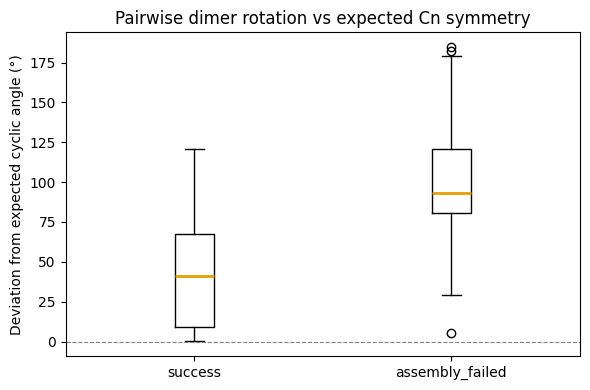

In [16]:
import scipy.stats as stats
import matplotlib.pyplot as plt

failed = angles_df.filter(pl.col("outcome") == "assembly_failed")["deviation_deg"].to_numpy()
success = angles_df.filter(pl.col("outcome") == "success")["deviation_deg"].to_numpy()

# 1. Statistical test
u_stat, p_val = stats.mannwhitneyu(failed, success, alternative="greater")
print(f"Mann-Whitney U: p = {p_val:.2e}")

# 2. Critical check: are high-deviation "successes" actually wrong structures?
# Join with TM-scores if you have them
# High deviation + success + low TM = spurious assembly, not a real success

# 3. Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([success, failed], labels=["success", "assembly_failed"], 
           medianprops=dict(color="#E69F00", linewidth=2))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="perfect match")
ax.set_ylabel("Deviation from expected cyclic angle (°)")
ax.set_title("Pairwise dimer rotation vs expected Cn symmetry")
plt.tight_layout()

What about complexes where onnly pooled model produced output

In [ ]:
'''
#result after running only the first cell
result_bigger = result.filter(pl.col("n_chains")>2)
result_bigger = result_bigger.filter((pl.col("cf_max_conf_path_pool").is_not_null())&(pl.col("cf_max_conf_path_pair").is_null()))

import subprocess

usalign = PRJ_ROOT/ "tools/usalign/USalign/USalign"

pred = "/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/6_sixth_subset_homomultimers_pool_vs_pair/CombFold/Q08457x4_pool_output/assembled_results/output_clustered_0.pdb"
ref  = "/cluster/project/beltrao/kdammer/master_thesis/data/Homomultimer/pdb_files/3x38/3x38.cif"

result = subprocess.run(
    [str(usalign), pred, ref, "-mm", "1", "-ter", "1", "-mol", "prot"],
    capture_output=True, text=True, check=True
)
print(result.stdout)

'''



In [8]:
only_pool_output = pl.read_parquet(PRJ_ROOT / "scripts/homomultimer_pool_pair_comparison/homomultimers_pool_only_usalign.parquet")

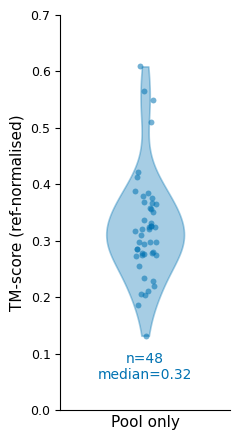

In [17]:
data = only_pool_output["tm_score_cpx_pool"].drop_nulls().to_numpy()
fig, ax = plt.subplots(figsize=(2.5, 4.5))

vp = ax.violinplot([data], positions=[0], widths=0.55, showmedians=False, showextrema=False)
vp["bodies"][0].set_facecolor("#0072B2")
vp["bodies"][0].set_alpha(0.35)
vp["bodies"][0].set_edgecolor("#0072B2")
vp["bodies"][0].set_linewidth(1.2)

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.08, 0.08, size=len(data))
ax.scatter(jitter, data, color="#0072B2", s=18, alpha=0.55, linewidths=0, zorder=2)


ax.text(
    0, 0.05,
    f"n={len(data)}\nmedian={np.median(data):.2f}",
    ha="center", va="bottom", fontsize=10, color="#0072B2",
)

ax.set_xticks([0])
ax.set_xticklabels(["Pool only"], fontsize=11)
ax.set_ylabel("TM-score (ref-normalised)", fontsize=11)
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", length=0)

plt.tight_layout()
plt.show()